# MineWatch V2 — Exploratory Data Analysis

**Academic EDA prototype.** This notebook analyses a synthetic, project-generated mining
dataset covering 30 fictional mines, monthly, from 2016-2024. It is inspired by the SIH 2026
problem statement SIH26024 (Coal Mine Governance & Compliance) but is **not** an official
government dataset, compliance system, or safety rating.

**Pipeline:** Load -> Inspect -> Clean (duplicates, categories, missing values) -> Outlier
inspection -> Derived metrics -> Univariate analysis -> Bivariate/multivariate analysis ->
Correlation -> Domain-specific analysis (production, safety, environment, economics,
regional) -> Final findings.


## Section 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## Section 2 - Load Dataset

In [3]:
df = pd.read_csv('minewatch_data.csv')
print(df.shape)
df.head()


(3272, 36)


,Mine_ID,Mine_Name,Region,State,Mine_Type,Commodity,Year,Month,Date,Production,Initial_Reserve,Remaining_Reserve,Workers,Working_Hours,Productivity_Index,Energy_Consumption,Commodity_Price,Revenue,Operating_Cost,Profit,Profit_Margin,Waste_Generation,Environmental_Impact,Environmental_Breach,Inspections,Violations,Violation_Category,Violation_Status,Safety_Incidents,Incident_Category,Severity,Risk_Factor,Corrective_Actions,Completed_Actions,Pending_Actions,Action_Status
0,MINE-029,Andhra Copper Mine 29,Southern,Andhra Pradesh,Open Cast,Copper Ore,2022,12,2022-12-01,45124.85,11305197.36,8225022.00,283,60927.5,0.7406,48236.04,8097.50,3653983.90,2953915.16,700068.73,19.16,10869.54,21.169,0,3,2,Operational,Under Review,0,NaN,NaN,2.44,2,1,1,Completed
1,MINE-002,West Iron Mine 2,Eastern,West Bengal,Open Cast,Iron Ore,2018,8,2018-08-01,65935.02,31788526.71,29229930.51,2020,397396.8,0.1659,63442.86,5604.55,3695360.07,3122691.29,572668.77,15.50,12928.10,31.710,0,0,1,Environmental,Closed,0,NaN,NaN,0.33,1,0,1,Completed
2,MINE-008,Telangana Iron Mine 8,Southern,Telangana,Open Cast,Iron Ore,2024,6,2024-06-01,21116.92,4242653.83,2652298.77,813,151019.5,0.1398,22087.50,7689.97,1623883.78,1231027.05,392856.73,24.19,6440.83,10.155,0,2,0,NaN,NaN,1,Fire,Minor,2.26,0,0,0,Completed
3,MINE-005,Madhya Coal Mine 5,Central,Madhya Pradesh,open cast,Coal,2018,2,2018-02-01,20049.92,6162270.35,5622249.18,1108,228650.9,0.0877,20692.18,2514.59,504173.29,366842.15,137331.14,27.24,5934.83,10.344,0,1,0,NaN,NaN,1,Electrical,Serious,1.52,0,0,0,Completed
4,MINE-010,Uttar Coal Mine 10,Northern,Uttar Pradesh,Mixed,Coal,2018,6,2018-06-01,23450.85,3804225.22,3281328.65,739,161536.2,0.1452,28271.86,2674.90,627286.55,509363.32,117923.22,18.80,11154.87,21.391,0,0,0,NaN,NaN,3,Machinery,Minor,1.71,0,0,0,Completed


## Section 3 - Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3272 entries, 0 to 3271
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mine_ID               3272 non-null   object 
 1   Mine_Name             3272 non-null   object 
 2   Region                3272 non-null   object 
 3   State                 3272 non-null   object 
 4   Mine_Type             3272 non-null   object 
 5   Commodity             3272 non-null   object 
 6   Year                  3272 non-null   int64  
 7   Month                 3272 non-null   int64  
 8   Date                  3272 non-null   object 
 9   Production            3272 non-null   float64
 10  Initial_Reserve       3272 non-null   float64
 11  Remaining_Reserve     3272 non-null   float64
 12  Workers               3272 non-null   int64  
 13  Working_Hours         3263 non-null   float64
 14  Productivity_Index    3272 non-null   float64
 15  Energy_Consumption   

In [5]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Year,3272.0,2.019998e+03,2.583547e+00,2.016000e+03,2.018000e+03,2.020000e+03,2.022000e+03,2.024000e+03
Month,3272.0,6.510391e+00,3.448430e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
Production,3272.0,4.598431e+04,5.708751e+04,2.809530e+03,1.266378e+04,2.679308e+04,5.845769e+04,5.698404e+05
Initial_Reserve,3272.0,9.377473e+06,6.909802e+06,1.715441e+06,4.595600e+06,6.248150e+06,1.165723e+07,3.178853e+07
Remaining_Reserve,3272.0,7.315343e+06,5.888980e+06,0.000000e+00,3.390189e+06,5.162437e+06,9.547320e+06,3.171231e+07
Workers,3272.0,9.996690e+02,6.087712e+02,1.150000e+02,5.390000e+02,9.025000e+02,1.211250e+03,3.779000e+03
Working_Hours,3263.0,2.000862e+05,1.227359e+05,2.240110e+04,1.090054e+05,1.777955e+05,2.461880e+05,7.677644e+05
Productivity_Index,3272.0,2.599292e-01,2.665238e-01,1.610000e-02,7.557500e-02,1.738000e-01,3.225250e-01,1.876900e+00
Energy_Consumption,3265.0,5.691788e+04,9.743912e+04,2.389110e+03,1.571570e+04,3.016687e+04,6.264418e+04,3.252588e+06
Commodity_Price,3263.0,4.170982e+03,2.248611e+03,5.889900e+02,2.454130e+03,3.729510e+03,5.762515e+03,1.179879e+04


In [6]:
df.describe(include='object').T

,count,unique,top,freq
Mine_ID,3272,30,MINE-010,111
Mine_Name,3272,30,Uttar Coal Mine 10,111
Region,3272,5,Eastern,984
State,3272,10,Odisha,331
Mine_Type,3272,10,Open Cast,1780
Commodity,3272,5,Iron Ore,1199
Date,3272,108,2017-06-01,32
Violation_Category,1041,18,Environmental,174
Violation_Status,1041,3,Under Review,354
Incident_Category,1435,7,Haulage/Transport,218


## Section 4 - Missing Values

In [7]:
missing_count = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
Violation_Status,2231,68.18
Violation_Category,2231,68.18
Severity,1837,56.14
Incident_Category,1837,56.14
Environmental_Impact,11,0.34
Working_Hours,9,0.28
Commodity_Price,9,0.28
Energy_Consumption,7,0.21


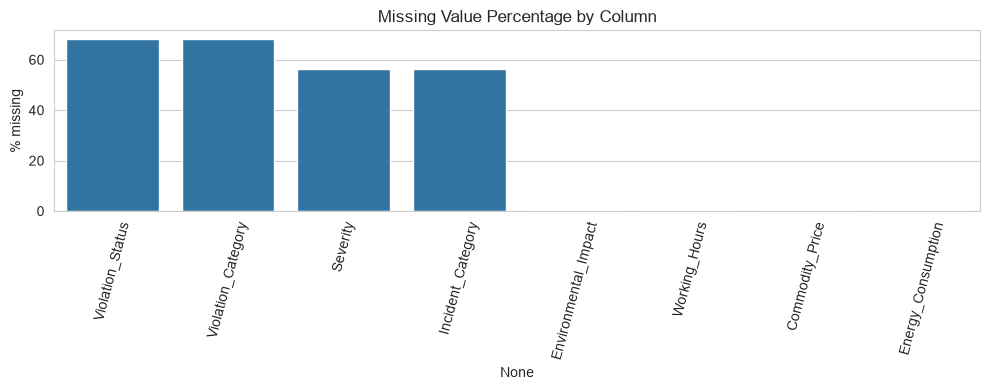

In [8]:
# Note: Violation_Category / Violation_Status / Incident_Category / Severity are
# legitimately missing when no violation/incident occurred that month - these are not
# data-quality problems, they are structural. Working_Hours, Energy_Consumption,
# Commodity_Price and Environmental_Impact contain genuine (small, intentional) missingness.
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'])
plt.xticks(rotation=75)
plt.ylabel('% missing')
plt.title('Missing Value Percentage by Column')
plt.tight_layout()
plt.show()


## Section 5 - Duplicate Detection

In [9]:
n_dupes = df.duplicated().sum()
print(f'Number of fully duplicated rows: {n_dupes}')
df[df.duplicated(keep=False)].sort_values('Mine_ID').head(10)


Number of fully duplicated rows: 32


,Mine_ID,Mine_Name,Region,State,Mine_Type,Commodity,Year,Month,Date,Production,Initial_Reserve,Remaining_Reserve,Workers,Working_Hours,Productivity_Index,Energy_Consumption,Commodity_Price,Revenue,Operating_Cost,Profit,Profit_Margin,Waste_Generation,Environmental_Impact,Environmental_Breach,Inspections,Violations,Violation_Category,Violation_Status,Safety_Incidents,Incident_Category,Severity,Risk_Factor,Corrective_Actions,Completed_Actions,Pending_Actions,Action_Status
2896,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2024,10,2024-10-01,424465.24,24608205.58,2766017.72,1981,429072.1,0.9893,552109.43,3070.26,13032181.30,10624842.06,2407339.24,18.47,92956.60,219.653,0,0,0,NaN,NaN,1,Fire,Minor,2.28,0,0,0,Completed
97,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2024,10,2024-10-01,424465.24,24608205.58,2766017.72,1981,429072.1,0.9893,552109.43,3070.26,13032181.30,10624842.06,2407339.24,18.47,92956.60,219.653,0,0,0,NaN,NaN,1,Fire,Minor,2.28,0,0,0,Completed
168,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2017,2,2017-02-01,85732.22,24608205.58,23572898.52,1123,212064.1,0.4043,104203.22,2637.47,2261157.58,1574305.99,686851.59,30.38,26837.67,52.638,0,1,0,NaN,NaN,2,Gas/Explosion,Minor,2.98,1,0,1,Completed
2101,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2017,2,2017-02-01,85732.22,24608205.58,23572898.52,1123,212064.1,0.4043,104203.22,2637.47,2261157.58,1574305.99,686851.59,30.38,26837.67,52.638,0,1,0,NaN,NaN,2,Gas/Explosion,Minor,2.98,1,0,1,Completed
178,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2024,3,2024-03-01,415496.81,24608205.58,5868213.85,2057,445897.5,0.9318,662788.30,2763.31,11481462.62,7280879.14,4200583.48,36.59,139362.64,276.060,0,1,0,NaN,NaN,1,Machinery,Moderate,1.30,0,0,0,Completed
1118,MINE-003,Odisha Coal Mine 3,Eastern,Odisha,Underground,Coal,2024,3,2024-03-01,415496.81,24608205.58,5868213.85,2057,445897.5,0.9318,662788.30,2763.31,11481462.62,7280879.14,4200583.48,36.59,139362.64,276.060,0,1,0,NaN,NaN,1,Machinery,Moderate,1.30,0,0,0,Completed
1674,MINE-004,Chhattisgarh Coal Mine 4,Central,Chhattisgarh,Underground,Coal,2016,8,2016-08-01,11882.47,3455223.81,3352946.21,1468,316640.4,0.0375,19395.17,2454.13,291611.32,200100.44,91510.88,31.38,2998.90,13.092,0,1,0,NaN,NaN,1,Haulage/Transport,Minor,0.82,0,0,0,Completed
310,MINE-004,Chhattisgarh Coal Mine 4,Central,Chhattisgarh,Underground,Coal,2016,8,2016-08-01,11882.47,3455223.81,3352946.21,1468,316640.4,0.0375,19395.17,2454.13,291611.32,200100.44,91510.88,31.38,2998.90,13.092,0,1,0,NaN,NaN,1,Haulage/Transport,Minor,0.82,0,0,0,Completed
26,MINE-005,Madhya Coal Mine 5,Central,Madhya Pradesh,Open Cast,Coal,2019,12,2019-12-01,14849.92,6162270.35,5262103.95,1091,203709.3,0.0729,17318.72,2332.00,346300.20,282394.59,63905.61,18.45,5349.14,9.668,0,2,2,Documentation,Open,1,Slip/Fall,Moderate,2.53,2,1,1,In Progress
117,MINE-005,Madhya Coal Mine 5,Central,Madhya Pradesh,Open Cast,Coal,2020,6,2020-06-01,14394.59,6162270.35,5173797.38,1041,220837.0,0.0652,17221.33,2514.25,361915.76,310579.42,51336.34,14.18,2734.60,14.187,0,2,0,NaN,NaN,0,NaN,NaN,1.87,0,0,0,Completed


## Section 6 - Data Cleaning

Cleaning steps, in order, with the reasoning for each:
1. **Duplicate removal** - exact duplicate rows add no information and would double-count
   production, incidents, revenue, etc. in any aggregation.
2. **Category normalization** - `Mine_Type` and `Violation_Category` contain
   case/hyphenation variants (e.g. `Open-Cast`, `open cast`, `OPEN CAST`) that must be
   unified to a canonical label before grouping.
3. **Date conversion** - `Date` is parsed to a proper datetime for time-series analysis.
4. **Missing value treatment** - the four genuinely-missing numeric columns are imputed
   with the **median for that specific mine** (falls back to global median), which
   preserves each mine's typical operating scale better than a single global median.
5. **Outlier inspection** - flagged and discussed, not blindly deleted (see the Outlier
   Analysis section below).


In [10]:
raw_rows = len(df)

# 1. Duplicate removal
df = df.drop_duplicates().reset_index(drop=True)
print(f'Rows before: {raw_rows}, after dedup: {len(df)}')


Rows before: 3272, after dedup: 3240


In [11]:
# 2. Category normalization
def norm_mine_type(v):
    if pd.isna(v):
        return v
    v2 = str(v).strip().lower().replace('-', ' ')
    mapping = {'open cast': 'Open Cast', 'underground': 'Underground', 'mixed': 'Mixed'}
    return mapping.get(v2, str(v).strip())

df['Mine_Type'] = df['Mine_Type'].apply(norm_mine_type)
df['Violation_Category'] = df['Violation_Category'].apply(lambda v: str(v).strip().title() if pd.notna(v) else v)

print(df['Mine_Type'].value_counts())
print()
print(df['Violation_Category'].value_counts(dropna=False))


Mine_Type
Open Cast      1836
Underground    1080
Mixed           324
Name: count, dtype: int64

Violation_Category
NaN                       2206
Equipment                  193
Environmental              183
Safety                     175
Documentation              167
Operational                165
Emergency Preparedness     151
Name: count, dtype: int64


In [12]:
# 3. Date conversion
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df.dtypes[['Date', 'Year', 'Month']]


Date     datetime64[ns]
Year              int64
Month             int64
dtype: object

In [13]:
# 4. Missing value treatment (median imputation, per mine)
cols_to_impute = ['Working_Hours', 'Energy_Consumption', 'Commodity_Price', 'Environmental_Impact']
before = df[cols_to_impute].isna().sum().sum()

for col in cols_to_impute:
    df[col] = df[col].fillna(df.groupby('Mine_ID')[col].transform('median'))
    df[col] = df[col].fillna(df[col].median())

after = df[cols_to_impute].isna().sum().sum()
print(f'Missing values in treated columns: {before} -> {after}')


Missing values in treated columns: 36 -> 0


## Derived Metrics

- `Energy_Intensity` = Energy_Consumption / Production
- `Waste_Intensity` = Waste_Generation / Production
- `Incident_Rate_per_1000h` = Safety_Incidents / Working_Hours * 1000


In [14]:
df['Energy_Intensity'] = (df['Energy_Consumption'] / df['Production']).replace([np.inf, -np.inf], np.nan)
df['Waste_Intensity'] = (df['Waste_Generation'] / df['Production']).replace([np.inf, -np.inf], np.nan)
df['Incident_Rate_per_1000h'] = (df['Safety_Incidents'] / df['Working_Hours'] * 1000).replace([np.inf, -np.inf], np.nan)
df[['Energy_Intensity', 'Waste_Intensity', 'Incident_Rate_per_1000h']].describe()


,Energy_Intensity,Waste_Intensity,Incident_Rate_per_1000h
count,3240.000000,3240.000000,3240.000000
mean,1.194645,0.342827,0.005330
std,0.342825,0.119640,0.012266
min,0.189318,0.035605,0.000000
25%,1.005367,0.255393,0.000000
50%,1.163437,0.335394,0.000000
75%,1.298429,0.416092,0.006268
max,9.635757,2.438176,0.168420


## Univariate Analysis

Distributions of the key individual variables.

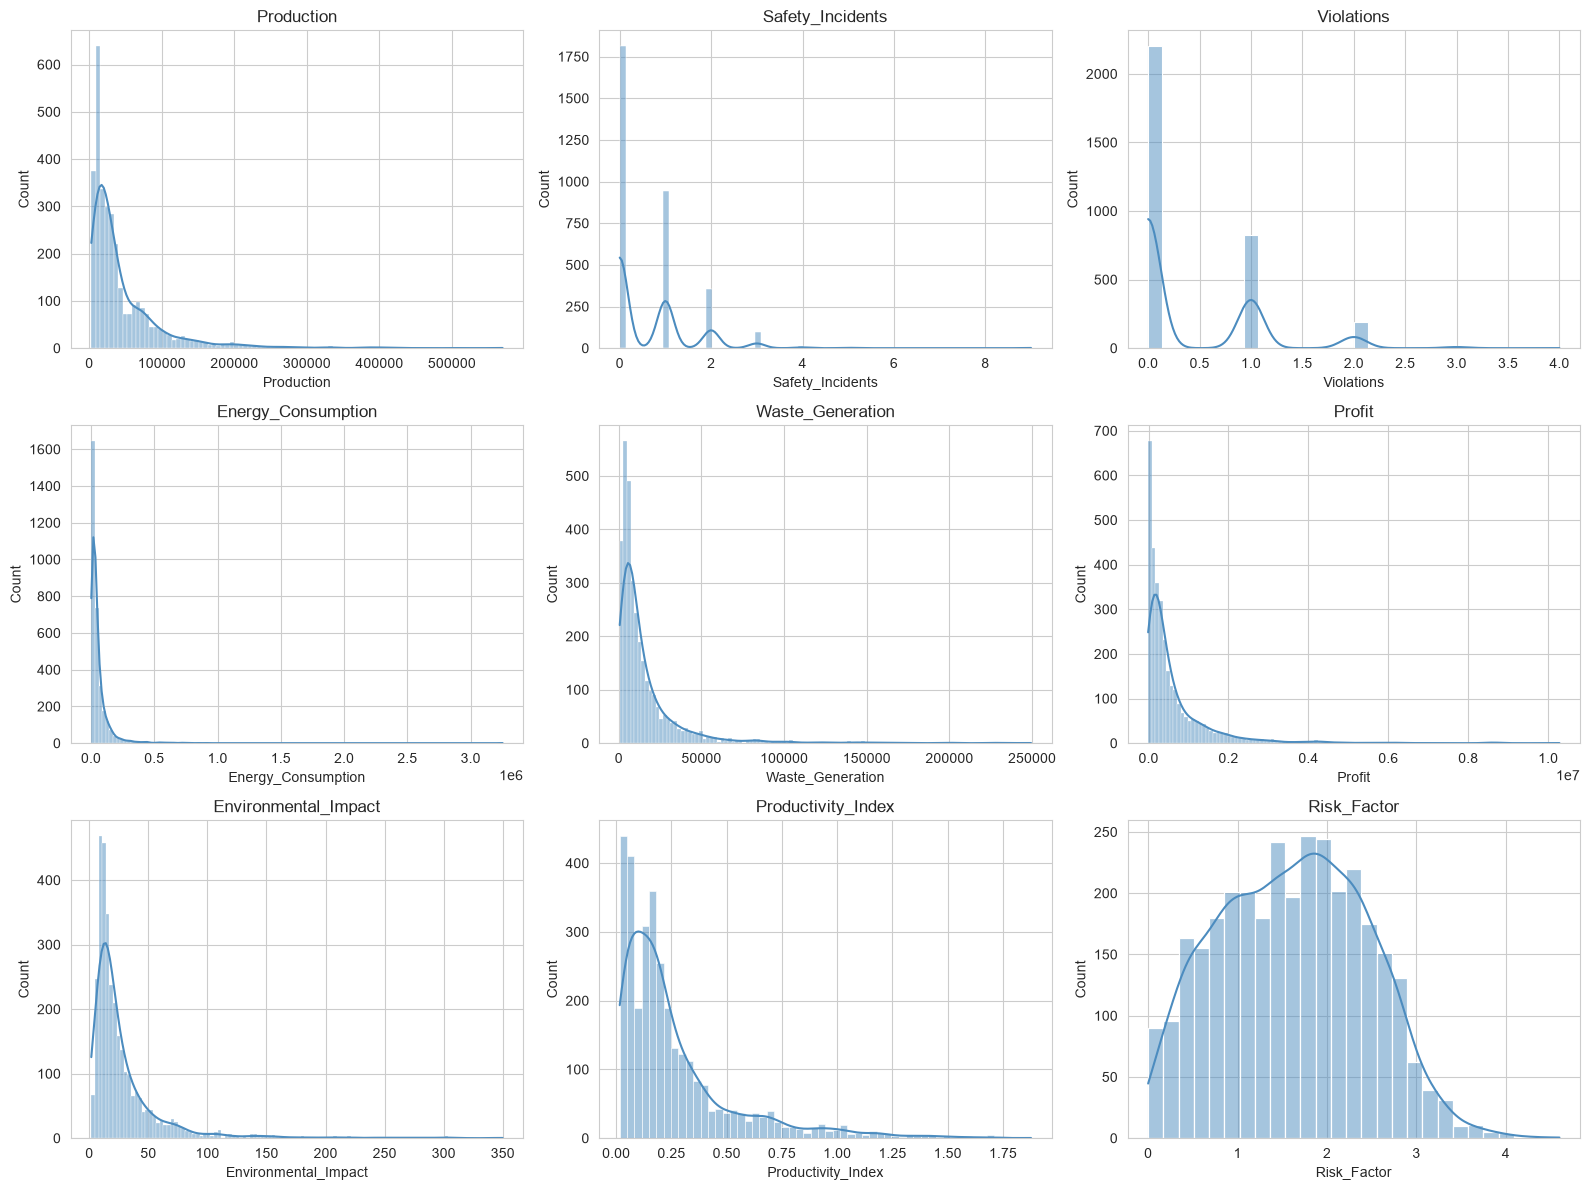

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
cols = ['Production', 'Safety_Incidents', 'Violations', 'Energy_Consumption',
        'Waste_Generation', 'Profit', 'Environmental_Impact', 'Productivity_Index', 'Risk_Factor']
for ax, col in zip(axes.flat, cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4C8CBF')
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Bivariate / Multivariate Analysis

Relationships between key operational, safety, environmental and economic variables.
Note: association shown here does not establish causation.


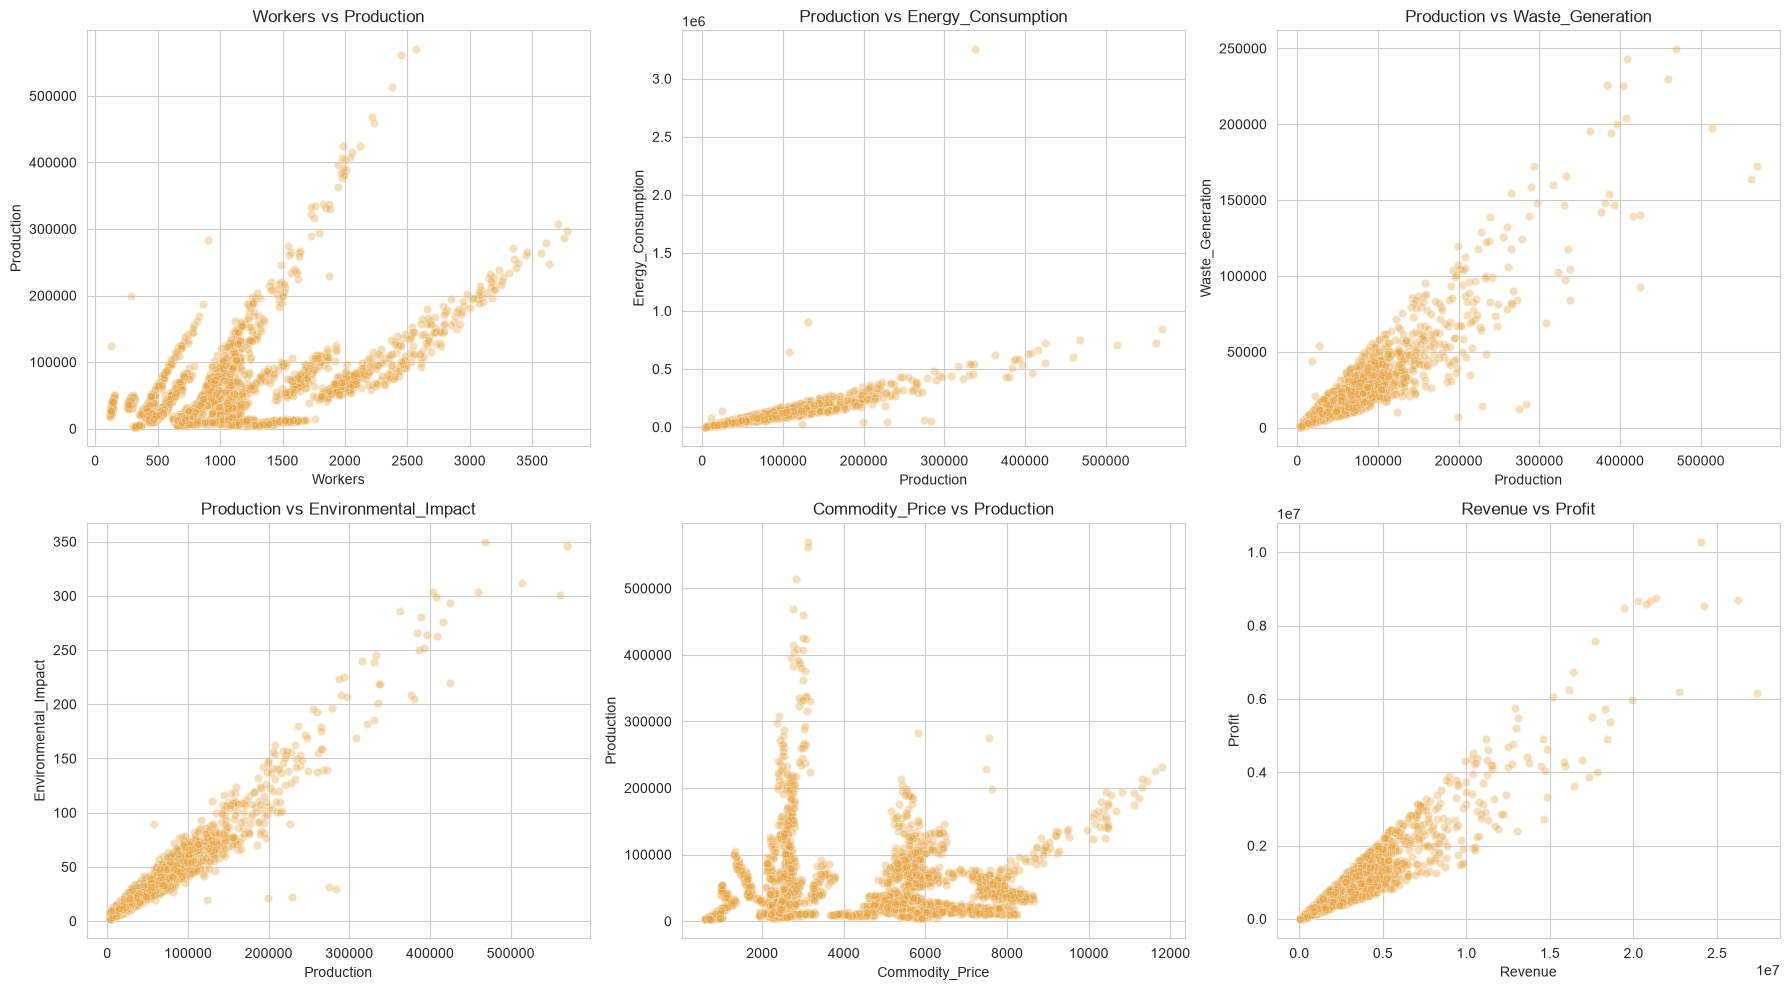

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pairs = [
    ('Workers', 'Production'),
    ('Production', 'Energy_Consumption'),
    ('Production', 'Waste_Generation'),
    ('Production', 'Environmental_Impact'),
    ('Commodity_Price', 'Production'),
    ('Revenue', 'Profit'),
]
for ax, (x, y) in zip(axes.flat, pairs):
    sns.scatterplot(data=df, x=x, y=y, alpha=0.35, ax=ax, color='#E8A33D')
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()


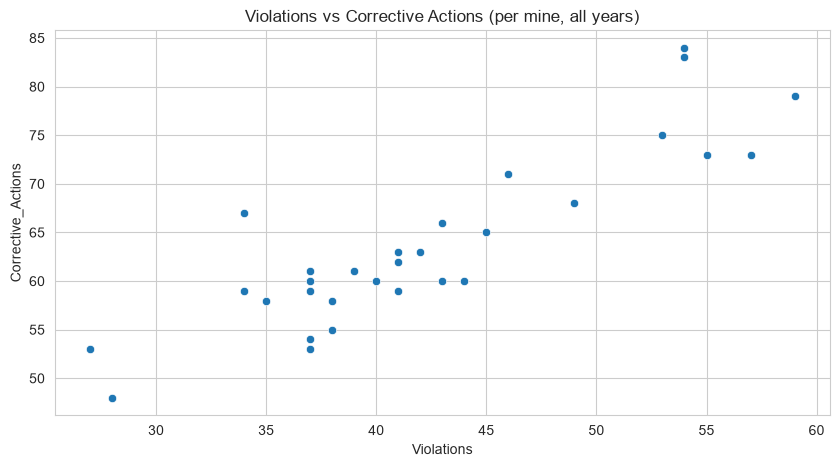

In [17]:
viol_ca = df.groupby('Mine_ID').agg({'Violations': 'sum', 'Corrective_Actions': 'sum'}).reset_index()
sns.scatterplot(data=viol_ca, x='Violations', y='Corrective_Actions')
plt.title('Violations vs Corrective Actions (per mine, all years)')
plt.show()


### Correlation Heatmap

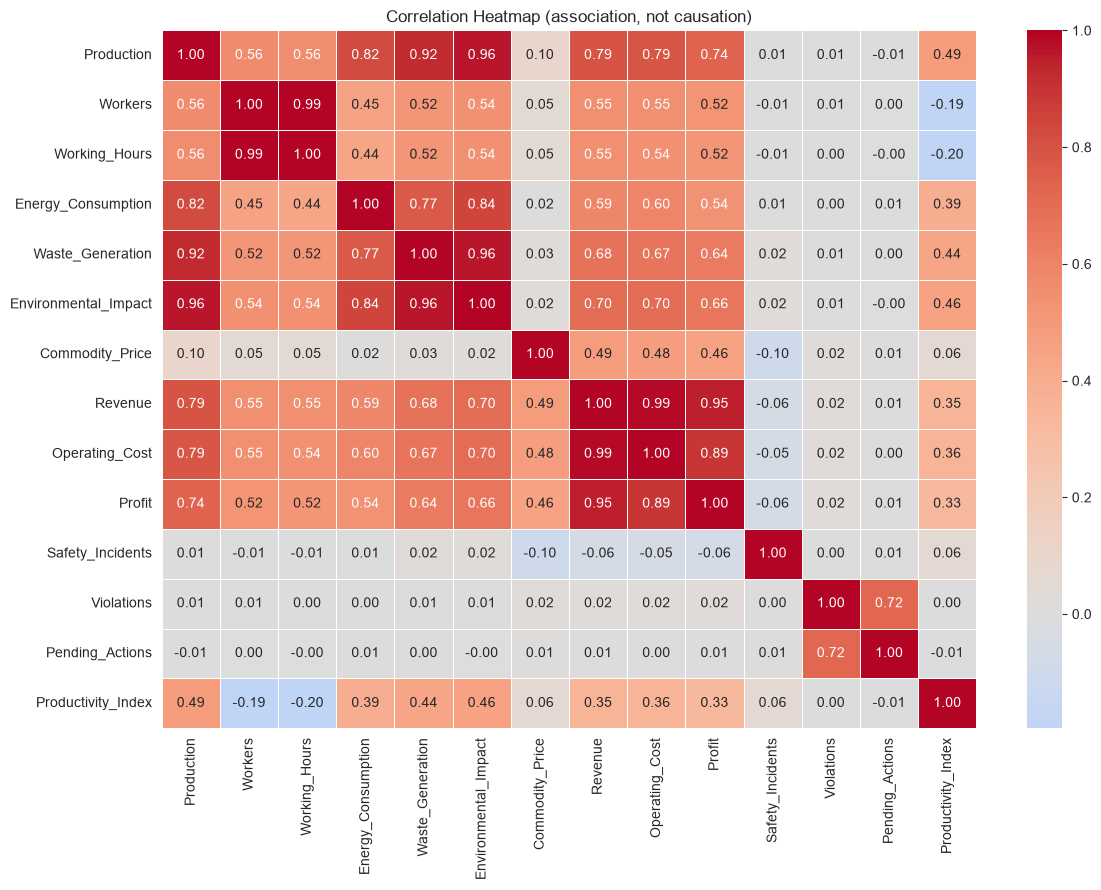

In [18]:
numeric_cols = ['Production', 'Workers', 'Working_Hours', 'Energy_Consumption',
                'Waste_Generation', 'Environmental_Impact', 'Commodity_Price', 'Revenue',
                'Operating_Cost', 'Profit', 'Safety_Incidents', 'Violations',
                'Pending_Actions', 'Productivity_Index']
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap (association, not causation)')
plt.tight_layout()
plt.show()


## Outlier Analysis (IQR method)

Outliers are flagged and discussed rather than automatically deleted - an outlier may
represent a genuine exceptional operational event, a data quality issue, or a rare but
real occurrence, and blind removal can hide real signal.

In [19]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ['Production', 'Energy_Consumption', 'Waste_Generation', 'Profit', 'Safety_Incidents']:
    out = iqr_outliers(df[col].dropna())
    print(f'{col}: {len(out)} potential outliers ({len(out)/len(df)*100:.2f}% of rows)')


Production: 235 potential outliers (7.25% of rows)
Energy_Consumption: 293 potential outliers (9.04% of rows)
Waste_Generation: 294 potential outliers (9.07% of rows)
Profit: 290 potential outliers (8.95% of rows)
Safety_Incidents: 120 potential outliers (3.70% of rows)


## Production Analysis

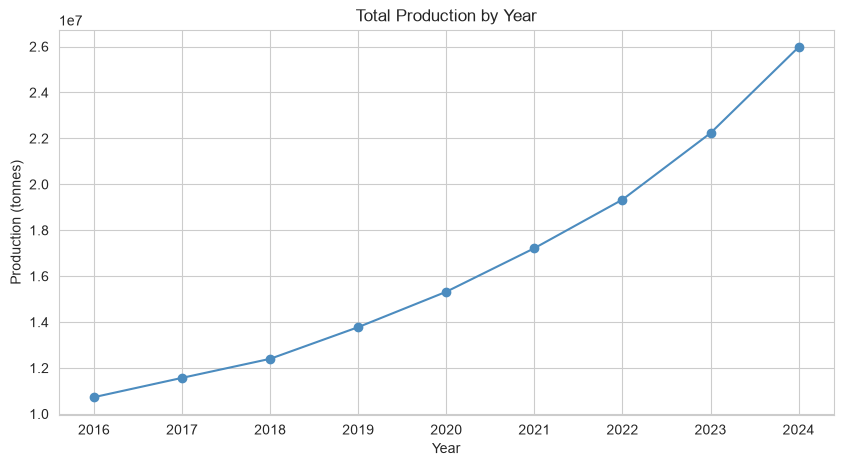

In [20]:
yearly_prod = df.groupby('Year')['Production'].sum()
yearly_prod.plot(marker='o', color='#4C8CBF')
plt.title('Total Production by Year')
plt.ylabel('Production (tonnes)')
plt.show()


## Productivity Analysis

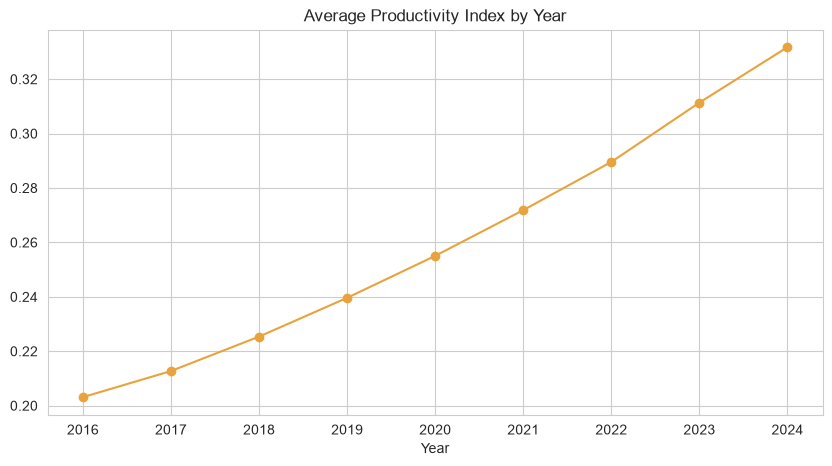

In [21]:
df.groupby('Year')['Productivity_Index'].mean().plot(marker='o', color='#E8A33D')
plt.title('Average Productivity Index by Year')
plt.show()


## Safety Analysis

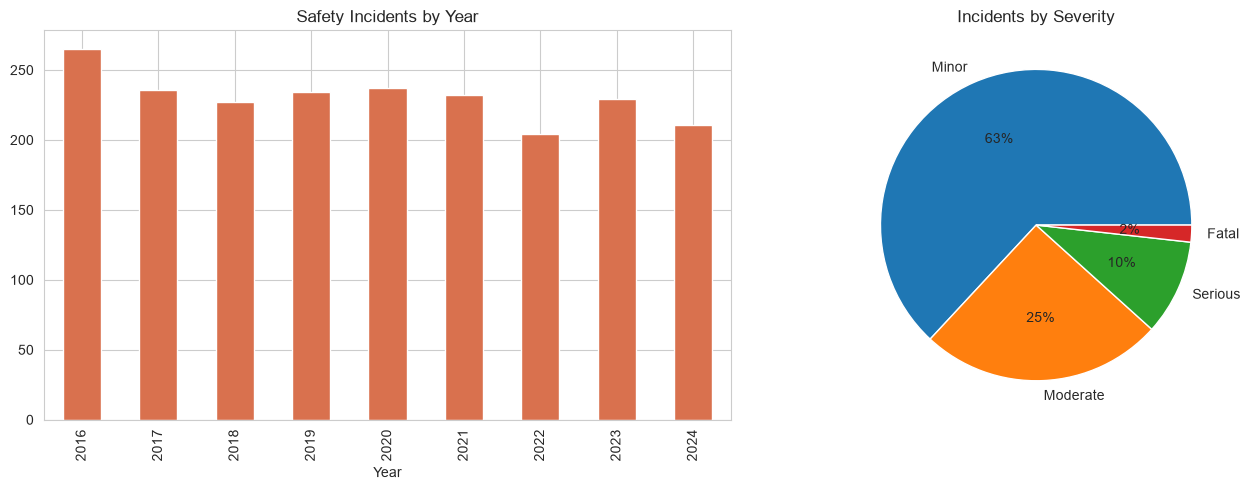

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Year')['Safety_Incidents'].sum().plot(kind='bar', ax=axes[0], color='#D9714E')
axes[0].set_title('Safety Incidents by Year')
df['Severity'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.0f%%')
axes[1].set_title('Incidents by Severity')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


## Environmental Analysis

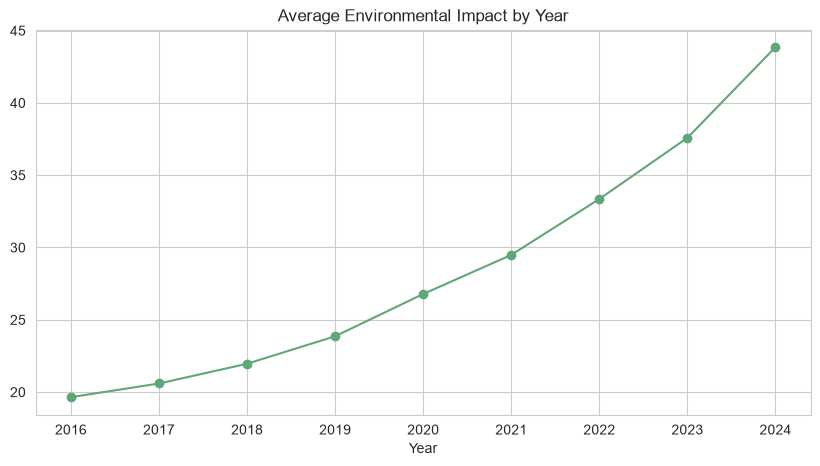

In [23]:
df.groupby('Year')['Environmental_Impact'].mean().plot(marker='o', color='#5FA777')
plt.title('Average Environmental Impact by Year')
plt.show()


## Energy Analysis

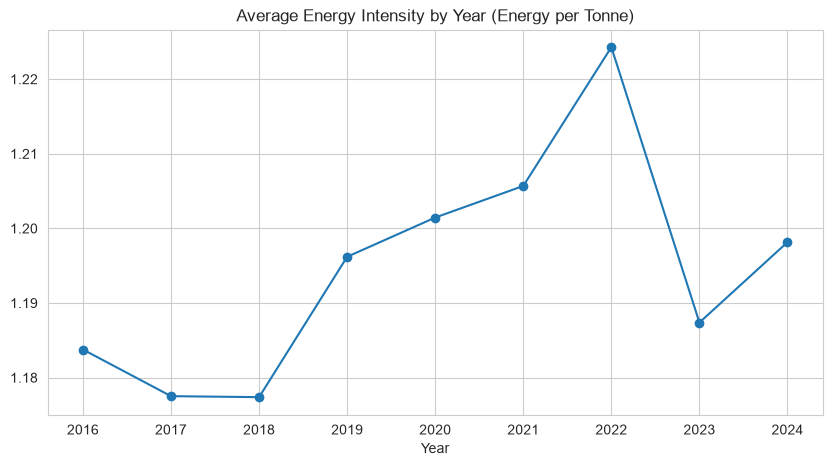

In [24]:
df.groupby('Year')['Energy_Intensity'].mean().plot(marker='o')
plt.title('Average Energy Intensity by Year (Energy per Tonne)')
plt.show()


## Waste Analysis

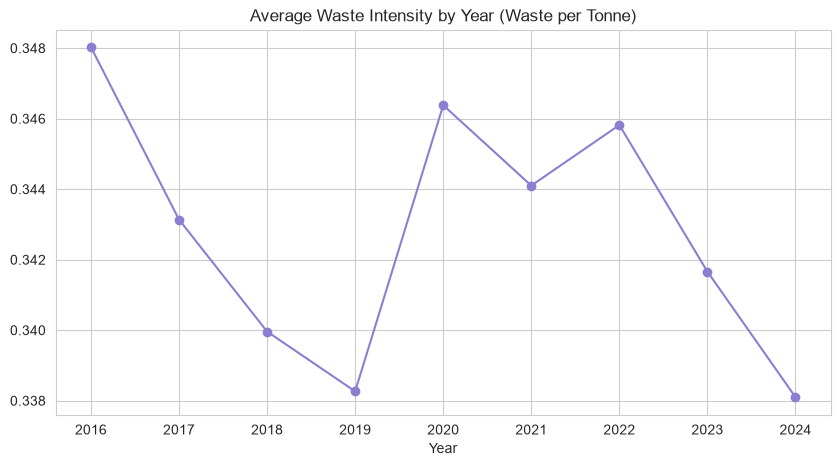

In [25]:
df.groupby('Year')['Waste_Intensity'].mean().plot(marker='o', color='#8B7FD1')
plt.title('Average Waste Intensity by Year (Waste per Tonne)')
plt.show()


## Economics

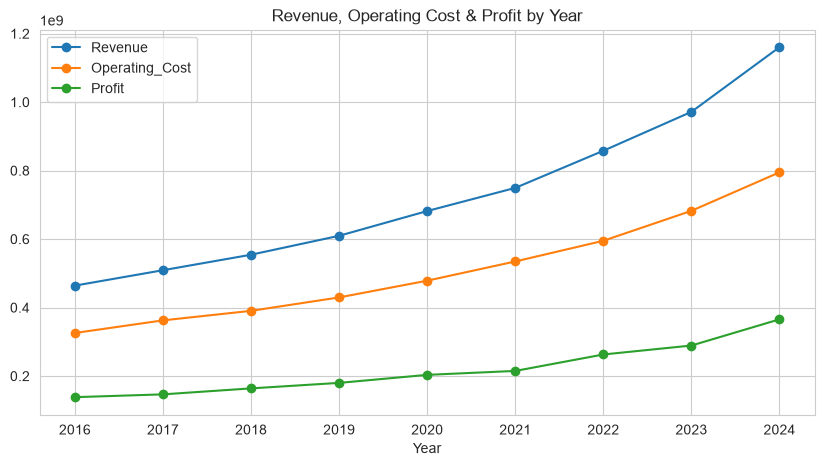

In [26]:
econ = df.groupby('Year')[['Revenue', 'Operating_Cost', 'Profit']].sum()
econ.plot(marker='o')
plt.title('Revenue, Operating Cost & Profit by Year')
plt.show()


## Regional Analysis

In [27]:
region_summary = df.groupby('Region').agg(
    Production=('Production', 'sum'),
    Productivity=('Productivity_Index', 'mean'),
    Safety_Incidents=('Safety_Incidents', 'sum'),
    Mines=('Mine_ID', 'nunique')
).sort_values('Production', ascending=False)
region_summary


,Production,Productivity,Safety_Incidents,Mines
Region,,,,
Eastern,9.212700e+07,0.349793,639,9
Central,1.853174e+07,0.131023,385,6
Southern,1.633407e+07,0.377532,475,6
Western,1.242740e+07,0.165091,334,6
Northern,9.135159e+06,0.203816,242,3


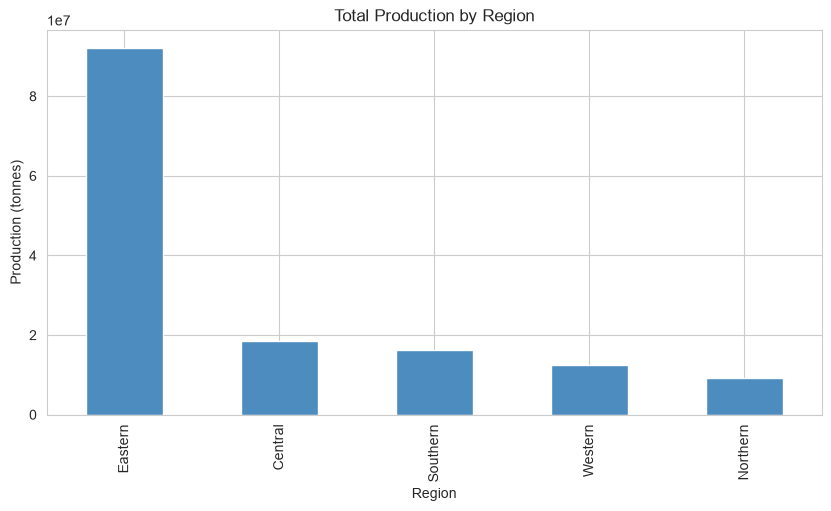

In [ ]:
region_summary['Production'].plot(kind='bar', color='#4C8CBF')
plt.title('Total Production by region')
plt.ylabel('Production (tonnes)')
plt.show()


## Final Findings

Summary observations derived directly from the cleaned dataset above (all figures are
computed, not hard-coded):

In [29]:
first_year, last_year = df['Year'].min(), df['Year'].max()
yearly = df.groupby('Year').agg(
    Production=('Production', 'sum'),
    Productivity=('Productivity_Index', 'mean'),
    Safety_Incidents=('Safety_Incidents', 'sum'),
    Violations=('Violations', 'sum'),
    Profit=('Profit', 'sum'),
)
first, last = yearly.loc[first_year], yearly.loc[last_year]

def pct(new, old):
    return (new - old) / abs(old) * 100 if old else float('nan')

print(f"Production changed {pct(last['Production'], first['Production']):+.1f}% from {first_year} to {last_year}")
print(f"Productivity changed {pct(last['Productivity'], first['Productivity']):+.1f}% from {first_year} to {last_year}")
print(f"Safety incidents changed {pct(last['Safety_Incidents'], first['Safety_Incidents']):+.1f}% from {first_year} to {last_year}")
print(f"Violations changed {pct(last['Violations'], first['Violations']):+.1f}% from {first_year} to {last_year}")
print(f"Profit changed {pct(last['Profit'], first['Profit']):+.1f}% from {first_year} to {last_year}")

if df['Violation_Category'].notna().any():
    top_cat = df['Violation_Category'].value_counts().idxmax()
    print(f"Most frequent violation category: {top_cat}")


Production changed +142.1% from 2016 to 2024
Productivity changed +63.3% from 2016 to 2024
Safety incidents changed -20.4% from 2016 to 2024
Violations changed +6.0% from 2016 to 2024
Profit changed +164.3% from 2016 to 2024
Most frequent violation category: Equipment


---
### Limitations
- All data in this notebook is **synthetic and project-generated** - it does not represent
  any real mine, company, or government record.
- Correlation analysis shows association only, not causation.
- This notebook supports the MineWatch V2 Streamlit dashboard (`app.py`) and uses the
  same dataset (`minewatch_data.csv`), generated by `generate_dataset.py`.
